In [44]:
#spark baslatma

In [45]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.conf import SparkConf
from pyspark import SparkContext


spark = SparkSession.builder \
    .master("local") \
    .appName("pyspark_uygulama") \
    .getOrCreate()



sc = spark.sparkContext
sc

<SparkContext master=local appName=pyspark_uygulama>

In [46]:
#veri yükleme
videos_df = spark.read.csv("../data/USvideos.csv", header=True, inferSchema=True)
cats_df = spark.read.option("multiline", "true").json("../data/US_category_id.json")


In [47]:
videos_df.printSchema()
videos_df.show(5)

root
 |-- video_id: string (nullable = true)
 |-- trending_date: string (nullable = true)
 |-- title: string (nullable = true)
 |-- channel_title: string (nullable = true)
 |-- category_id: string (nullable = true)
 |-- publish_time: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- views: string (nullable = true)
 |-- likes: string (nullable = true)
 |-- dislikes: string (nullable = true)
 |-- comment_count: string (nullable = true)
 |-- thumbnail_link: string (nullable = true)
 |-- comments_disabled: string (nullable = true)
 |-- ratings_disabled: string (nullable = true)
 |-- video_error_or_removed: string (nullable = true)
 |-- description: string (nullable = true)

+-----------+-------------+--------------------+--------------------+-----------+--------------------+--------------------+-------+------+--------+-------------+--------------------+-----------------+----------------+----------------------+--------------------+
|   video_id|trending_date|               t

In [48]:
#kategori id olusturma
from pyspark.sql.functions import explode, col

cats_exploded = cats_df.select(explode('items').alias('item'))
cats_final = cats_exploded.select(
    col("item.id").alias("category_id"),
    col("item.snippet.title").alias("category_name")
)
cats_final = cats_final.withColumn("category_id", col("category_id").cast("string"))
cats_final.show(10)


+-----------+----------------+
|category_id|   category_name|
+-----------+----------------+
|          1|Film & Animation|
|          2|Autos & Vehicles|
|         10|           Music|
|         15|  Pets & Animals|
|         17|          Sports|
|         18|    Short Movies|
|         19| Travel & Events|
|         20|          Gaming|
|         21|   Videoblogging|
|         22|  People & Blogs|
+-----------+----------------+
only showing top 10 rows


In [49]:
#category_id integer cast dönüşümü
from pyspark.sql.functions import col

videos_df = videos_df.withColumn("category_id", col("category_id").cast("string"))
videos_joined = videos_df.join(cats_final, on="category_id", how="left")

videos_joined.select("title", "category_name", "views", "likes", "dislikes").show(5)


+--------------------+--------------+-------+------+--------+
|               title| category_name|  views| likes|dislikes|
+--------------------+--------------+-------+------+--------+
|WE WANT TO TALK A...|People & Blogs| 748374| 57527|    2966|
|The Trump Preside...| Entertainment|2418783| 97185|    6146|
|Racist Superman |...|        Comedy|3191434|146033|    5339|
|Nickelback Lyrics...| Entertainment| 343168| 10172|     666|
|I Dare You: GOING...| Entertainment|2095731|132235|    1989|
+--------------------+--------------+-------+------+--------+
only showing top 5 rows


In [50]:
from pyspark.sql.functions import col, sum

#hatali satırları düzelt
videos_clean = videos_joined.filter(
    ~(
        col("views").rlike("[A-Za-z]") |
        col("likes").rlike("[A-Za-z]") |
        col("dislikes").rlike("[A-Za-z]") |
        col("comment_count").rlike("[A-Za-z]")
    )
)


In [51]:

#kolonları double yaptık çünkü spark bazen str olarak saklıyor
videos_clean = videos_clean.withColumn("views", col("views").cast("double")) \
                           .withColumn("likes", col("likes").cast("double")) \
                           .withColumn("dislikes", col("dislikes").cast("double")) \
                           .withColumn("comment_count", col("comment_count").cast("double"))


In [ ]:

#kategoriye göre toplam izlenme sayısı
views_by_cat = videos_clean.groupBy("category_name") \
    .agg(sum("views").alias("total_views")) \
    .orderBy(col("total_views").desc())
    

views_by_cat.cache()
views_by_cat.show(10)


+--------------------+---------------+
|       category_name|    total_views|
+--------------------+---------------+
|               Music| 4.013289219E10|
|       Entertainment|2.0604388195E10|
|    Film & Animation|  7.284156721E9|
|              Comedy|  5.117426208E9|
|      People & Blogs|  4.917191726E9|
|              Sports|  4.404456673E9|
|       Howto & Style|  4.078545064E9|
|Science & Technology|  3.487756816E9|
|              Gaming|  2.141218625E9|
|     News & Politics|  1.473765704E9|
+--------------------+---------------+
only showing top 10 rows


In [53]:
views_by_cat = videos_clean.groupBy("category_name") \
    .agg(sum("views").alias("total_views")) \
    .orderBy(col("total_views").desc())

views_by_cat.show(100)


+--------------------+---------------+
|       category_name|    total_views|
+--------------------+---------------+
|               Music| 4.013289219E10|
|       Entertainment|2.0604388195E10|
|    Film & Animation|  7.284156721E9|
|              Comedy|  5.117426208E9|
|      People & Blogs|  4.917191726E9|
|              Sports|  4.404456673E9|
|       Howto & Style|  4.078545064E9|
|Science & Technology|  3.487756816E9|
|              Gaming|  2.141218625E9|
|     News & Politics|  1.473765704E9|
|           Education|   1.18062999E9|
|      Pets & Animals|   7.64651989E8|
|    Autos & Vehicles|   5.20690717E8|
|     Travel & Events|   3.43557084E8|
|Nonprofits & Acti...|   1.68941392E8|
|               Shows|    5.1501058E7|
+--------------------+---------------+



In [54]:
from pyspark.sql.functions import (col, expr)

videos_clean = videos_clean.withColumn("like_ratio", expr("likes / (likes + dislikes)"))
videos_clean.select("title", "category_name", "like_ratio").show(5)


+--------------------+--------------+------------------+
|               title| category_name|        like_ratio|
+--------------------+--------------+------------------+
|WE WANT TO TALK A...|People & Blogs|0.9509695336650521|
|The Trump Preside...| Entertainment|0.9405212375763323|
|Racist Superman |...|        Comedy|0.9647292762201728|
|Nickelback Lyrics...| Entertainment| 0.938549547887064|
|I Dare You: GOING...| Entertainment|0.9851814876624151|
+--------------------+--------------+------------------+
only showing top 5 rows


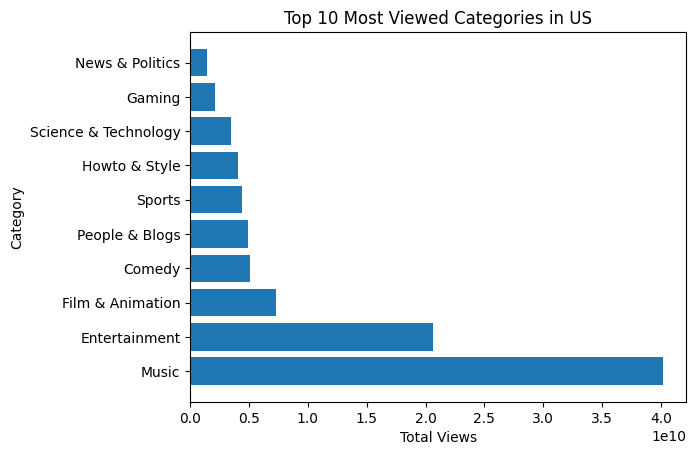

In [55]:
sample_df = views_by_cat.limit(10).toPandas()

import matplotlib.pyplot as plt
plt.barh(sample_df["category_name"], sample_df["total_views"])
plt.xlabel("Total Views")
plt.ylabel("Category")
plt.title("Top 10 Most Viewed Categories in US")
plt.show()


In [58]:
spark.stop()